In [4]:
from datasets import load_dataset

# Standard-format mirror of the ADE Corpus (no loading script needed)
ds = load_dataset("SetFit/ade_corpus_v2_classification")
ds

Repo card metadata block was not found. Setting CardData to empty.
Generating train split: 17637 examples [00:00, 329619.87 examples/s]
Generating test split: 5879 examples [00:00, 775394.27 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 17637
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 5879
    })
})

In [5]:
import pandas as pd

df = ds["train"].to_pandas()
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head(10)

Rows: 17637
Columns: ['text', 'label', 'label_text']


,text,label,label_text
0,"On cessation of the injections, the retrocorne...",0,Not-Related
1,Median patient age was 52 years.,0,Not-Related
2,A whole brain irradiation was performed for 37...,0,Not-Related
3,Complex biochemical syndrome of hypocalcemia a...,0,Not-Related
4,The fastidious organism grew only on buffered ...,0,Not-Related
5,A patient who developed necrotizing pancreatit...,0,Not-Related
6,RESULTS: Evidence of neurological improvement ...,1,Related
7,Diagnosis is often difficult and is typically ...,0,Not-Related
8,An associated finding included a 2+ positive a...,0,Not-Related
9,Patients in the intensive care unit seldom hav...,0,Not-Related


In [6]:
print("--- An ADE example (label 1) ---")
print(df[df.label == 1]["text"].iloc[0])
print("\n--- A non-ADE example (label 0) ---")
print(df[df.label == 0]["text"].iloc[0])

--- An ADE example (label 1) ---
RESULTS: Evidence of neurological improvement and rehabilitation potential after severe myelopathy due to intrathecal injection of doxorubicin.

--- A non-ADE example (label 0) ---
On cessation of the injections, the retrocorneal membrane grew rapidly to involve the entire posterior cornea.


In [7]:
print(df["label_text"].value_counts())
print()
print(df["label"].value_counts(normalize=True).round(3))

label_text
Not-Related    12492
Related         5145
Name: count, dtype: int64

label
0    0.708
1    0.292
Name: proportion, dtype: float64


In [8]:
X_train, y_train = ds["train"]["text"], ds["train"]["label"]
X_test,  y_test  = ds["test"]["text"],  ds["test"]["label"]
len(X_train), len(X_test)

(17637, 5879)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# TF-IDF: represent each sentence by which words it uses, weighted so rare/informative words count more.
# Logistic regression: learns a weight for each word — how much it pushes toward "ADE" vs "not".
model = make_pipeline(
    TfidfVectorizer(min_df=5, ngram_range=(1,2)),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(min_df=5, ngram_range=(1, 2))),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)
print(classification_report(y_test, pred, target_names=["Not-Related", "Related"]))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

 Not-Related       0.88      0.96      0.92      4203
     Related       0.86      0.66      0.75      1676

    accuracy                           0.87      5879
   macro avg       0.87      0.81      0.83      5879
weighted avg       0.87      0.87      0.87      5879

[[4023  180]
 [ 562 1114]]


In [11]:
model_balanced = make_pipeline(
    TfidfVectorizer(min_df=5, ngram_range=(1,2)),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
model_balanced.fit(X_train, y_train)

pred_b = model_balanced.predict(X_test)
print(classification_report(y_test, pred_b, target_names=["Not-Related", "Related"]))
print(confusion_matrix(y_test, pred_b))

              precision    recall  f1-score   support

 Not-Related       0.94      0.88      0.91      4203
     Related       0.73      0.85      0.79      1676

    accuracy                           0.87      5879
   macro avg       0.84      0.87      0.85      5879
weighted avg       0.88      0.87      0.87      5879

[[3686  517]
 [ 244 1432]]


In [12]:
import numpy as np

vec  = model_balanced.named_steps["tfidfvectorizer"]
clf  = model_balanced.named_steps["logisticregression"]
words = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]

print("Top words pushing TOWARD 'ADE':")
print(list(words[np.argsort(coefs)[-15:]][::-1]))
print("\nTop words pushing AWAY from 'ADE':")
print(list(words[np.argsort(coefs)[:15]]))

Top words pushing TOWARD 'ADE':
['induced', 'associated', 'developed', 'after', 'neurotoxicity', 'toxicity', 'following', 'receiving', 'lithium', 'hypersensitivity', 'during', 'methotrexate', 'cause', 'interferon', 'taking']

Top words pushing AWAY from 'ADE':
['was', 'were', 'showed', 'drug induced', 'transplantation', 'is', 'chemotherapy', 'corticosteroids', 'this', 'these', 'the', 'surgery', 'not', 'agents', 'drugs']


In [13]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

encoder = SentenceTransformer("all-MiniLM-L6-v2")   # downloads ~90MB the first time

s = [
    "The patient developed severe liver toxicity after taking the drug.",  # an ADE
    "Following treatment, the medication caused serious liver damage.",     # same meaning, different words
    "The study was conducted at three hospitals over two years.",          # unrelated
]
emb = encoder.encode(s)
print("Each sentence is now a vector of shape:", emb.shape)

print("ADE vs paraphrase (should be HIGH):", round(float(cos_sim(emb[0], emb[1])), 2))
print("ADE vs unrelated  (should be LOW): ", round(float(cos_sim(emb[0], emb[2])), 2))

ModuleNotFoundError: No module named 'sentence_transformers'

In [14]:
import sys
!{sys.executable} -m pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 4.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 5.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 4.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 4.2 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 3.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 4.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: huggingface-hub━━━━━━━━━━━━━━━━━━━  5/10 [torch]kx]
    Found existing installation: huggingface_hub 1.8.0━━━━━━━━  5/10 [torch]
    Uninstalling huggingface_hub-1.8.0:━━━━━━━━━━━━━━━━━━━  5/10 [torch]
      Successfully uninstalled huggingface_hub-1.8.0━━━━━━━━━━  5/10 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [sentence-transformers]ence-transformers]


In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

encoder = SentenceTransformer("all-MiniLM-L6-v2")   # downloads ~90MB the first time

s = [
    "The patient developed severe liver toxicity after taking the drug.",  # an ADE
    "Following treatment, the medication caused serious liver damage.",     # same meaning, different words
    "The study was conducted at three hospitals over two years.",          # unrelated
]
emb = encoder.encode(s)
print("Each sentence is now a vector of shape:", emb.shape)

print("ADE vs paraphrase (should be HIGH):", round(float(cos_sim(emb[0], emb[1])), 2))
print("ADE vs unrelated  (should be LOW): ", round(float(cos_sim(emb[0], emb[2])), 2))

/Users/belalzaky/Projects/adr-reader/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/belalzaky/Projects/adr-reader/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Each sentence is now a vector of shape: (3, 384)
ADE vs paraphrase (should be HIGH): 0.84
ADE vs unrelated  (should be LOW):  0.25


In [2]:
from datasets import load_dataset
ds = load_dataset("SetFit/ade_corpus_v2_classification")
X_train, y_train = ds["train"]["text"], ds["train"]["label"]
X_test,  y_test  = ds["test"]["text"],  ds["test"]["label"]
len(X_train), len(X_test)

Repo card metadata block was not found. Setting CardData to empty.


(17637, 5879)

In [3]:
X_train_emb = encoder.encode(list(X_train), batch_size=64, show_progress_bar=True)
X_test_emb  = encoder.encode(list(X_test),  batch_size=64, show_progress_bar=True)
X_train_emb.shape

Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:21<00:00,  4.31it/s]


(17637, 384)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

clf_emb = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_emb.fit(X_train_emb, y_train)

pred_emb = clf_emb.predict(X_test_emb)
print(classification_report(y_test, pred_emb, target_names=["Not-Related", "Related"]))
print(confusion_matrix(y_test, pred_emb))

              precision    recall  f1-score   support

 Not-Related       0.93      0.81      0.86      4203
     Related       0.64      0.84      0.73      1676

    accuracy                           0.82      5879
   macro avg       0.78      0.82      0.80      5879
weighted avg       0.84      0.82      0.83      5879

[[3409  794]
 [ 271 1405]]


In [5]:
bio_encoder = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO")   # ~420MB, biomedical

Xtr_bio = bio_encoder.encode(list(X_train), batch_size=64, show_progress_bar=True)
Xte_bio = bio_encoder.encode(list(X_test),  batch_size=64, show_progress_bar=True)

clf_bio = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr_bio, y_train)
pred_bio = clf_bio.predict(Xte_bio)
print(classification_report(y_test, pred_bio, target_names=["Not-Related", "Related"]))

Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [01:16<00:00,  1.20it/s]


              precision    recall  f1-score   support

 Not-Related       0.96      0.89      0.92      4203
     Related       0.76      0.90      0.83      1676

    accuracy                           0.89      5879
   macro avg       0.86      0.89      0.87      5879
weighted avg       0.90      0.89      0.89      5879



In [6]:
import sys; !{sys.executable} -m pip install ollama

SyntaxError: invalid syntax (2510950499.py, line 1)

In [7]:
import sys
!{sys.executable} -m pip install ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 661.5 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ollama]2m3/5 [pydantic]


In [10]:
import ollama, json

def extract_ade(sentence):
    prompt = f"""You are a pharmacovigilance assistant. Decide whether the sentence describes an adverse drug event (a drug CAUSING a harmful or unwanted effect).

Return ONLY JSON with these keys:
- "is_ade": true or false
- "drug": the drug name if an ADE is described, otherwise null
- "effect": the adverse effect if an ADE is described, otherwise null

Sentence: "{sentence}"
"""
    resp = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        format="json",          # forces valid JSON output
    )
    return json.loads(resp["message"]["content"])

In [11]:
tests = [
    "RESULTS: Evidence of neurological improvement and rehabilitation potential after severe myelopathy due to intrathecal injection of doxorubicin.",  # gold: ADE (doxorubicin -> myelopathy)
    "The drug significantly improved the patient's kidney function.",  # not an ADE
    "On cessation of the injections, the retrocorneal membrane grew rapidly to involve the entire posterior cornea.",  # gold: not tagged ADE
]
for t in tests:
    print("•", t[:75], "...")
    print("   →", extract_ade(t), "\n")

• RESULTS: Evidence of neurological improvement and rehabilitation potential  ...
   → {'is_ade': False, 'drug': 'doxorubicin', 'effect': 'neurological improvement'} 

• The drug significantly improved the patient's kidney function. ...
   → {'is_ade': False, 'drug': 'null', 'effect': 'null'} 

• On cessation of the injections, the retrocorneal membrane grew rapidly to i ...
   → {'is_ade': True, 'drug': None, 'effect': 'retrocorneal membrane growth involving the entire posterior cornea'} 



In [12]:
import random
from tqdm import tqdm

random.seed(0)
N = 150
idx = random.sample(range(len(X_test)), N)
sample_texts = [X_test[i] for i in idx]
sample_gold  = [y_test[i] for i in idx]

preds_llm, raw = [], []
for t in tqdm(sample_texts):
    try:
        out = extract_ade(t)
    except Exception as e:
        out = {"error": str(e)}
    raw.append(out)
    ade = out.get("is_ade") in (True, "true", "True")
    preds_llm.append(1 if ade else 0)

100%|████████████████████████████████████████| 150/150 [03:41<00:00,  1.48s/it]


In [13]:
from sklearn.metrics import classification_report

print(classification_report(sample_gold, preds_llm, target_names=["Not-Related", "Related"]))

incons = sum(
    1 for o in raw
    if o.get("is_ade") in (True, "true", "True")
    and o.get("drug") in (None, "null", "", "None")
)
print(f"\nContradictions (said ADE but gave no drug): {incons} / {N}")

              precision    recall  f1-score   support

 Not-Related       0.93      0.75      0.83       104
     Related       0.61      0.87      0.71        46

    accuracy                           0.79       150
   macro avg       0.77      0.81      0.77       150
weighted avg       0.83      0.79      0.79       150


Contradictions (said ADE but gave no drug): 3 / 150


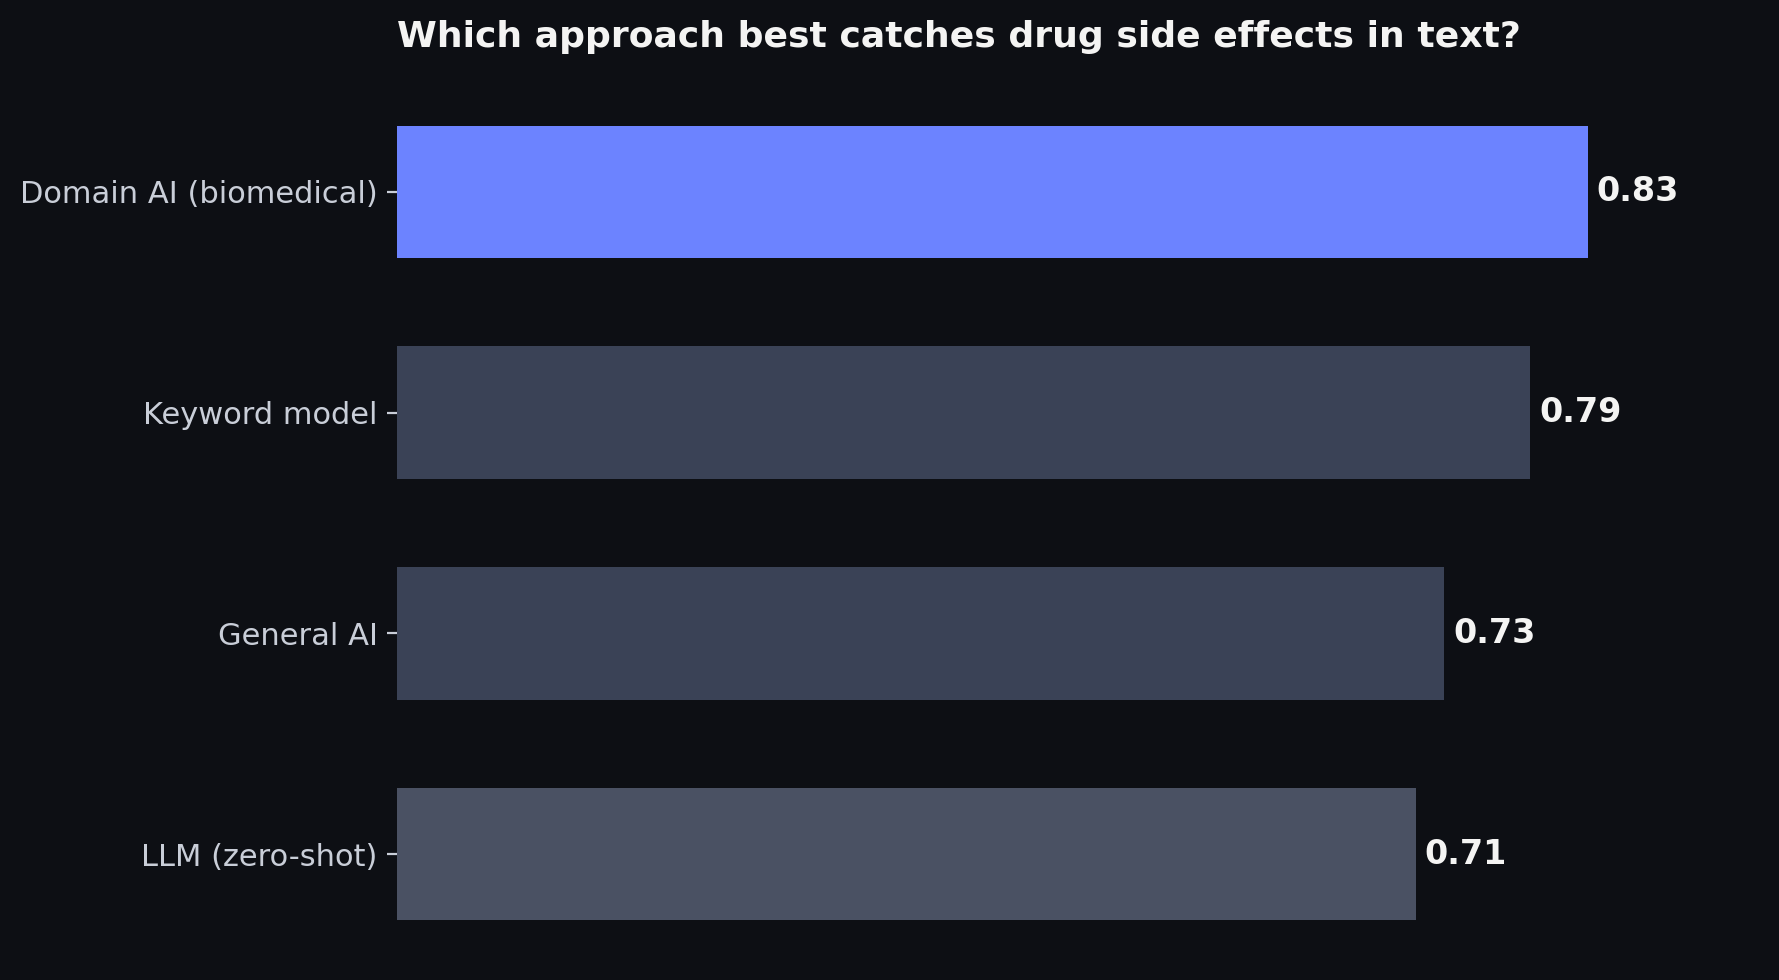

In [14]:
import matplotlib.pyplot as plt

models = ["Domain AI (biomedical)", "Keyword model", "General AI", "LLM (zero-shot)"]
f1     = [0.83, 0.79, 0.73, 0.71]
colors = ["#6c83ff", "#3a4256", "#3a4256", "#4a5163"]   # winner in accent

fig, ax = plt.subplots(figsize=(9, 5), dpi=200)
fig.patch.set_facecolor("#0d0f14"); ax.set_facecolor("#0d0f14")
bars = ax.barh(models[::-1], f1[::-1], color=colors[::-1], height=0.6)
for b, v in zip(bars, f1[::-1]):
    ax.text(v + 0.006, b.get_y()+b.get_height()/2, f"{v:.2f}",
            va="center", color="#f4f4f3", fontsize=12, fontweight="bold")
ax.set_xlim(0, 0.95)
ax.set_title("Which approach best catches drug side effects in text?",
             color="#f4f4f3", fontsize=13, fontweight="bold", loc="left", pad=14)
ax.tick_params(colors="#c9ced8", labelsize=11)
for s in ax.spines.values(): s.set_visible(False)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.savefig("scoreboard.png", facecolor="#0d0f14", bbox_inches="tight", dpi=200)
plt.show()

/var/folders/zd/yf87tfl97r73pvx0c9swb5km0000gn/T/ipykernel_36788/43975495.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(order, color="#1f2a44")


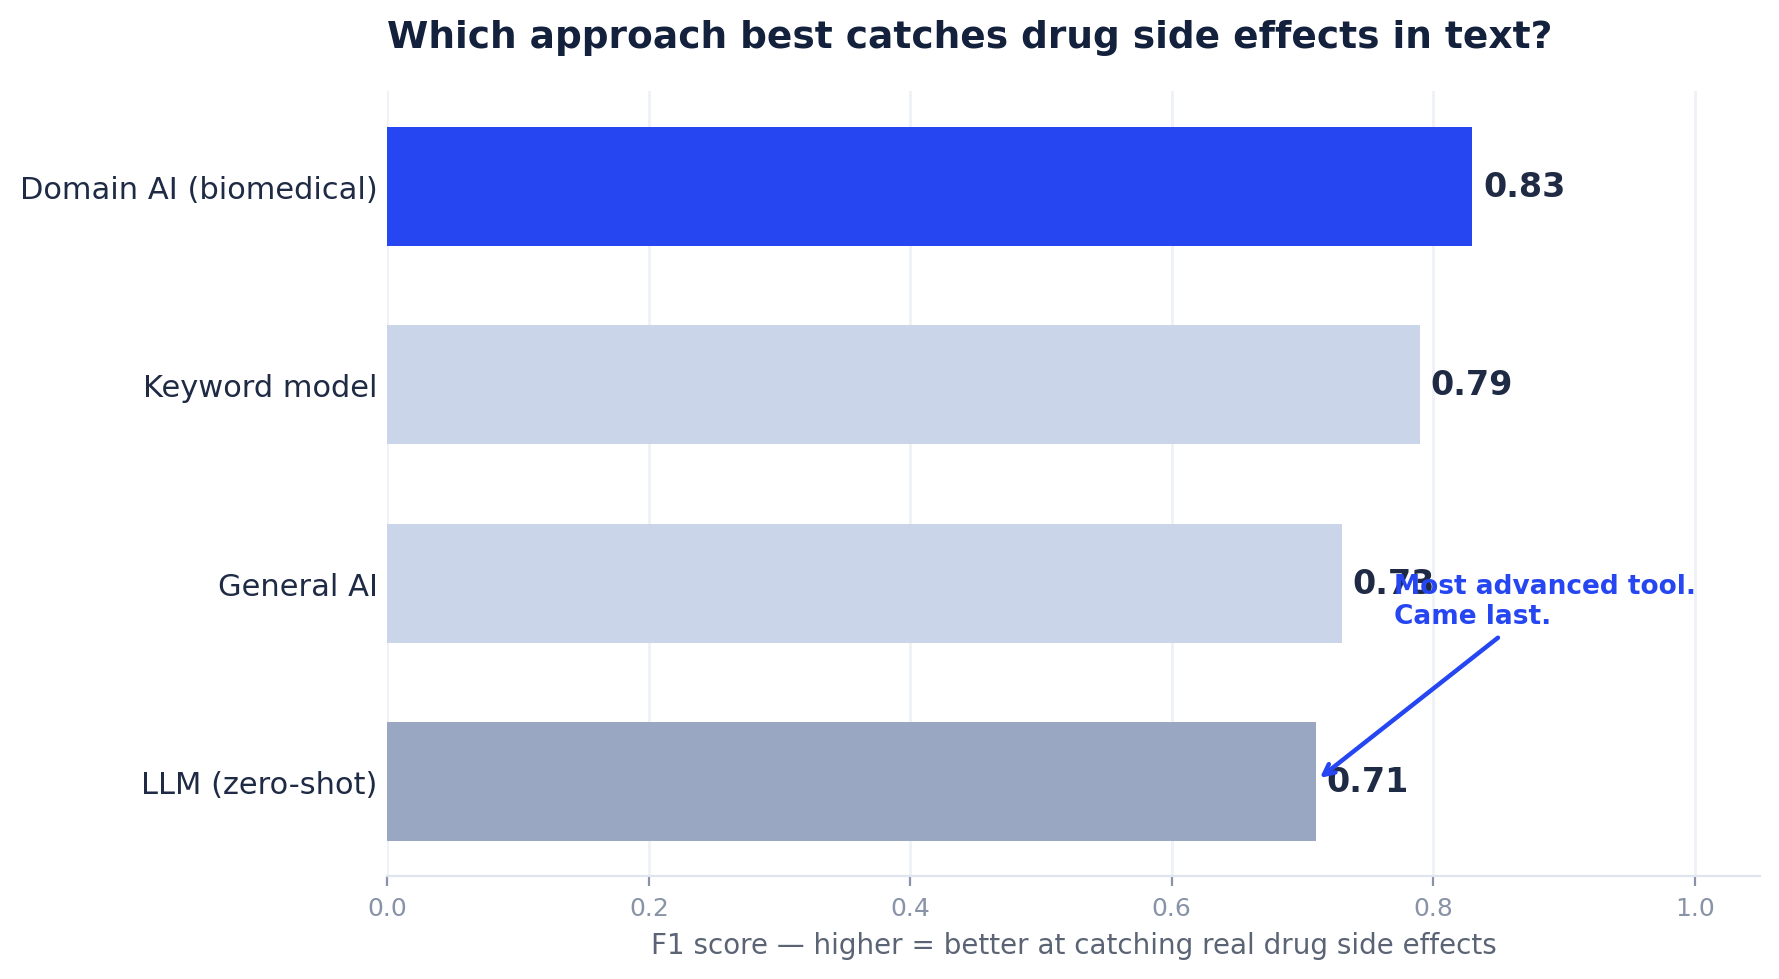

In [15]:
import matplotlib.pyplot as plt

order = ["LLM (zero-shot)", "General AI", "Keyword model", "Domain AI (biomedical)"]
vals  = [0.71, 0.73, 0.79, 0.83]
cols  = ["#9aa7c2", "#cbd5ea", "#cbd5ea", "#2546f0"]   # winner in accent; LLM a touch darker

fig, ax = plt.subplots(figsize=(9, 5), dpi=200)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

ax.barh(order, vals, color=cols, height=0.6)
for i, v in enumerate(vals):
    ax.text(v + 0.008, i, f"{v:.2f}", va="center", color="#1f2a44",
            fontsize=12, fontweight="bold")

ax.set_xlim(0, 1.05)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis="x", colors="#8893a8", labelsize=9)
ax.tick_params(axis="y", length=0, labelsize=11)
ax.set_yticklabels(order, color="#1f2a44")
ax.set_xlabel("F1 score — higher = better at catching real drug side effects",
              color="#5b6474", fontsize=10)
ax.set_title("Which approach best catches drug side effects in text?",
             color="#14213d", fontsize=13.5, fontweight="bold", loc="left", pad=16)
ax.grid(axis="x", color="#eef1f6", linewidth=1); ax.set_axisbelow(True)
for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color("#dfe4ee")

# callout on the LLM bar (bottom bar, y=0)
ax.annotate("Most advanced tool.\nCame last.", xy=(0.71, 0), xytext=(0.77, 0.8),
            color="#2546f0", fontsize=9.5, fontweight="bold", ha="left",
            arrowprops=dict(arrowstyle="->", color="#2546f0", lw=1.6))

plt.tight_layout()
plt.savefig("scoreboard.png", facecolor="white", bbox_inches="tight", dpi=200)
plt.show()

/var/folders/zd/yf87tfl97r73pvx0c9swb5km0000gn/T/ipykernel_36788/886296483.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(order, color="#14213d")


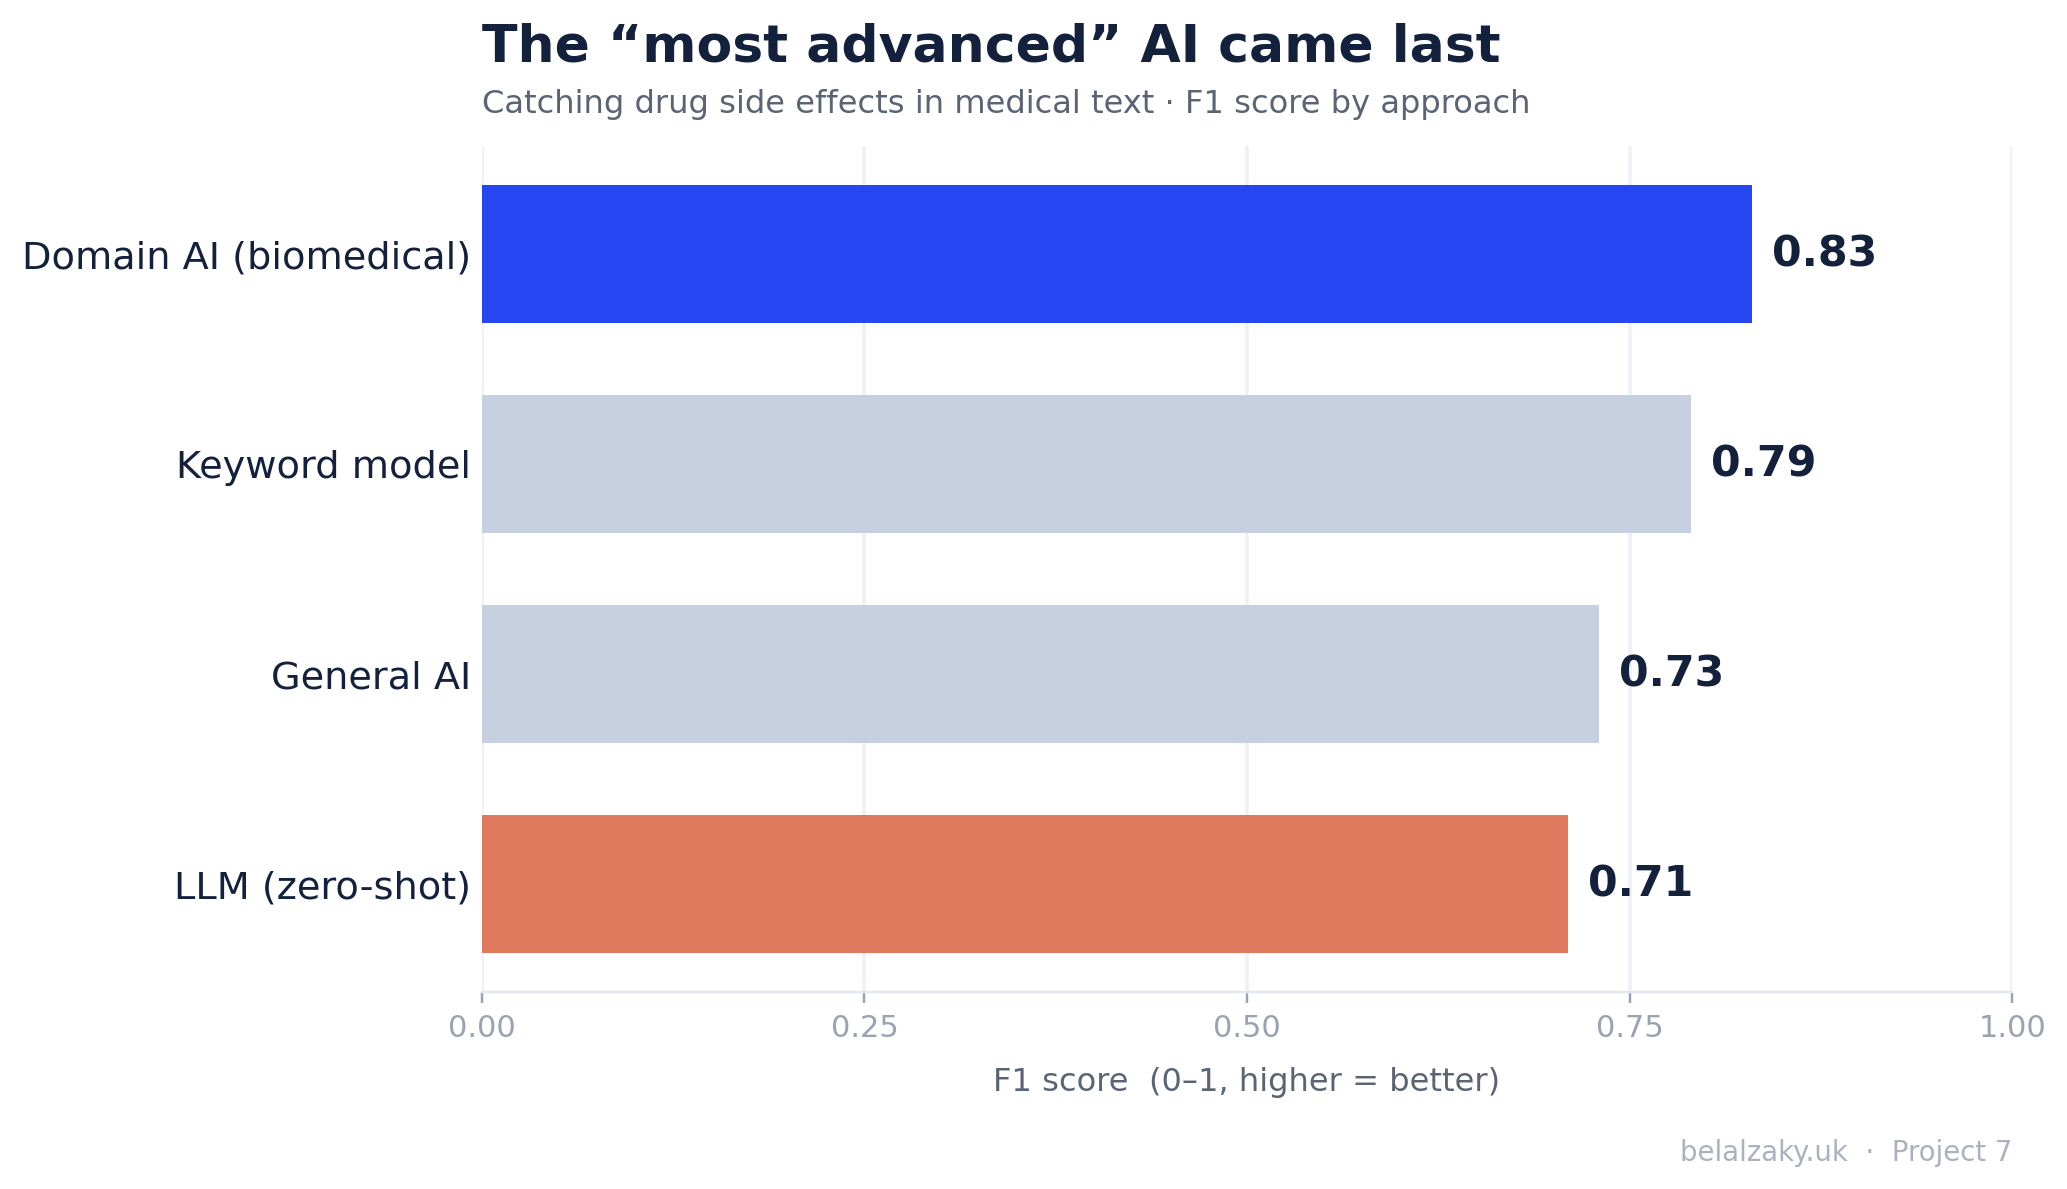

In [16]:
import matplotlib.pyplot as plt

order = ["LLM (zero-shot)", "General AI", "Keyword model", "Domain AI (biomedical)"]
vals  = [0.71, 0.73, 0.79, 0.83]
cols  = ["#e07a5f", "#c7d0e0", "#c7d0e0", "#2546f0"]   # LLM warm = underperformer, winner = accent

fig, ax = plt.subplots(figsize=(9.5, 5.6), dpi=220)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

ax.barh(order, vals, color=cols, height=0.66, zorder=3)
for i, v in enumerate(vals):
    ax.text(v + 0.013, i, f"{v:.2f}", va="center", ha="left",
            color="#14213d", fontsize=14, fontweight="bold", zorder=4)

ax.set_xlim(0, 1.0)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("F1 score  (0–1, higher = better)", color="#5b6474", fontsize=10.5, labelpad=8)
ax.tick_params(axis="x", colors="#9aa3b2", labelsize=10)
ax.tick_params(axis="y", length=0, labelsize=12.5)
ax.set_yticklabels(order, color="#14213d")
ax.grid(axis="x", color="#eef1f6", linewidth=1.2, zorder=0); ax.set_axisbelow(True)
for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color("#e3e8f0")

ax.set_title("The \u201cmost advanced\u201d AI came last", color="#14213d",
             fontsize=17, fontweight="bold", loc="left", pad=28)
ax.text(0, 1.04, "Catching drug side effects in medical text \u00b7 F1 score by approach",
        transform=ax.transAxes, color="#5b6474", fontsize=10.5)
ax.text(1.0, -0.2, "belalzaky.uk  \u00b7  Project 7", transform=ax.transAxes,
        ha="right", color="#aab2c0", fontsize=9)

plt.tight_layout()
plt.savefig("scoreboard.png", facecolor="white", bbox_inches="tight", dpi=220)
plt.show()

In [17]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# 6 curated sentences that show the models agreeing AND disagreeing
examples = [
    {"text":"RESULTS: Evidence of neurological improvement and rehabilitation potential after severe myelopathy due to intrathecal injection of doxorubicin.",
     "gold":1, "drug":"doxorubicin", "effect":"myelopathy"},
    {"text":"The patient developed acute renal failure after receiving high-dose methotrexate.",
     "gold":1, "drug":"methotrexate", "effect":"acute renal failure"},
    {"text":"Hepatotoxicity was observed in three patients treated with isoniazid.",
     "gold":1, "drug":"isoniazid", "effect":"hepatotoxicity"},
    {"text":"Lithium was effective in reducing manic episodes, with no adverse effects reported.",
     "gold":0, "drug":"lithium", "effect":None},
    {"text":"On cessation of the injections, the retrocorneal membrane grew rapidly to involve the entire posterior cornea.",
     "gold":0, "drug":None, "effect":None},
    {"text":"This study reviewed the pharmacokinetics of ibuprofen in healthy volunteers.",
     "gold":0, "drug":None, "effect":None},
]
texts = [e["text"] for e in examples]

# keyword baseline — retrain inline (it predates the kernel restart)
model_kw = make_pipeline(TfidfVectorizer(min_df=5, ngram_range=(1,2)),
                         LogisticRegression(max_iter=1000, class_weight="balanced"))
model_kw.fit(X_train, y_train)

def safe_extract(t):
    try: return extract_ade(t)
    except Exception as e: return {"is_ade": False, "drug": None, "effect": None, "error": str(e)}

pred_keyword = model_kw.predict(texts)
pred_general = clf_emb.predict(encoder.encode(texts))
pred_domain  = clf_bio.predict(bio_encoder.encode(texts))
llm_out      = [safe_extract(t) for t in texts]
pred_llm     = [1 if o.get("is_ade") in (True,"true","True") else 0 for o in llm_out]

for i, e in enumerate(examples):
    e["models"]  = {"keyword":int(pred_keyword[i]), "general":int(pred_general[i]),
                    "domain":int(pred_domain[i]), "llm":pred_llm[i]}
    e["correct"] = {k:(v==e["gold"]) for k,v in e["models"].items()}
    e["llm_extracted"] = {"drug":llm_out[i].get("drug"), "effect":llm_out[i].get("effect")}

with open("project7_examples.json","w") as f:
    json.dump({"examples":examples,
               "scoreboard":{"keyword":0.79,"general":0.73,"domain":0.83,"llm":0.71}},
              f, indent=2)

print("Wrote project7_examples.json")
for e in examples:
    print("gold", e["gold"], e["models"], "| true:", e["drug"], "/", e["effect"])

Wrote project7_examples.json
gold 1 {'keyword': 1, 'general': 1, 'domain': 0, 'llm': 0} | true: doxorubicin / myelopathy
gold 1 {'keyword': 1, 'general': 1, 'domain': 1, 'llm': 1} | true: methotrexate / acute renal failure
gold 1 {'keyword': 1, 'general': 1, 'domain': 1, 'llm': 1} | true: isoniazid / hepatotoxicity
gold 0 {'keyword': 0, 'general': 0, 'domain': 0, 'llm': 0} | true: lithium / None
gold 0 {'keyword': 0, 'general': 0, 'domain': 0, 'llm': 1} | true: None / None
gold 0 {'keyword': 0, 'general': 0, 'domain': 0, 'llm': 0} | true: None / None


In [18]:
import numpy as np

kw = model_kw.predict(sample_texts)
ge = clf_emb.predict(encoder.encode(sample_texts))
do = clf_bio.predict(bio_encoder.encode(sample_texts))
ll = np.array(preds_llm)
preds = np.vstack([kw, ge, do, ll]).T          # columns: keyword, general, domain, llm
gold  = np.array(sample_gold)

split = preds.std(axis=1) > 0                    # models disagree with each other
print("disagreement cases (kw/ge/do/llm | gold | sentence):\n")
for i in np.where(split)[0][:30]:
    print(preds[i], "| gold", gold[i], "|", sample_texts[i][:95])

disagreement cases (kw/ge/do/llm | gold | sentence):

[0 1 1 0] | gold 0 | CONCLUSION: This report shows thatimmune-mediateddiabetes mellitus can occur as a late complica
[0 0 0 1] | gold 0 | In this report, we present a rare case of gastro-duodenal ulcer following selective internal ra
[0 0 0 1] | gold 0 | Two adverse effects were reported: 1 case of reversible urinary retention and 1 case of deficie
[0 0 1 1] | gold 0 | After commencing oestrogen at physiological replacement doses, the patient experienced a marked
[0 0 0 1] | gold 0 | A 25-year-old woman with rheumatoid arthritis for the past 5 years started to develop gradual e
[0 1 0 1] | gold 0 | Subsequent management with topical steroids was complicated as the patient was a steroid respon
[1 0 1 1] | gold 1 | An episode of leukoencephalopathy is reported in a 13-year-old girl who, after standard radioth
[0 0 0 1] | gold 0 | Liposomal amphotericin B was prescribed at the standard dose of 5 mg/kg/day; however, amphoteri
[1 0 1 0] 

In [ ]:
import json

curated = [
  {"text":"RESULTS: Evidence of neurological improvement and rehabilitation potential after severe myelopathy due to intrathecal injection of doxorubicin.",
   "gold":1,"drug":"doxorubicin","effect":"myelopathy"},                       # keyword wins; domain+LLM fooled
  {"text":"Hepatotoxicity was observed in three patients treated with isoniazid.",
   "gold":1,"drug":"isoniazid","effect":"hepatotoxicity"},                     # clean positive (all agree)
  {"text":"Lithium was effective in reducing manic episodes, with no adverse effects reported.",
   "gold":0,"drug":"lithium","effect":None},                                   # clean negative (all agree)
  {"text":"On cessation of the injections, the retrocorneal membrane grew rapidly to involve the entire posterior cornea.",
   "gold":0,"drug":None,"effect":None},                                        # LLM cries wolf
]

def find(kw):
    for i,t in enumerate(sample_texts):
        if kw.lower() in t.lower():
            return {"text":t, "gold":int(sample_gold[i]), "drug":None, "effect":None}
for kw in ["ticlopidine", "leukoencephalopathy"]:
    m = find(kw)
    if m: curated.append(m)

texts = [e["text"] for e in curated]
pk = model_kw.predict(texts)
pg = clf_emb.predict(encoder.encode(texts))
pd = clf_bio.predict(bio_encoder.encode(texts))
lo = [safe_extract(t) for t in texts]
pl = [1 if o.get("is_ade") in (True,"true","True") else 0 for o in lo]

for i,e in enumerate(curated):
    e["models"]  = {"keyword":int(pk[i]),"general":int(pg[i]),"domain":int(pd[i]),"llm":pl[i]}
    e["correct"] = {k:(v==e["gold"]) for k,v in e["models"].items()}
    e["llm_extracted"] = {"drug":lo[i].get("drug"),"effect":lo[i].get("effect")}
    if not e["drug"]:   e["drug"]   = lo[i].get("drug")     # fall back to LLM extraction for highlight
    if not e["effect"]: e["effect"] = lo[i].get("effect")

with open("project7_examples.json","w") as f:
    json.dump({"examples":curated,
               "scoreboard":{"keyword":0.79,"general":0.73,"domain":0.83,"llm":0.71}}, f, indent=2)

print("Wrote", len(curated), "examples")
for e in curated:
    print("gold",e["gold"],e["models"],"|",e["text"][:80])